In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import matplotlib as mpl
mpl.rcParams["svg.fonttype"] = "path"
mpl.rcParams["pdf.fonttype"] = 42

In [4]:
results_df = pd.read_csv("../outputs/tracerx/summary.csv")
results_df

,num_stages,min_alt_freq,num_alt,max_alt_per_pathway,seed,num_strictly_consistent_patients,num_partially_consistent_patients,time_took_problem,time_took_other,avg_alterations_per_pathway,num_null_datasets,p1_value,effect_size
0,1,8,16,3.0,1,63,0,0.030923,11.421284,3.0,1000,1.000,-0.515457
1,1,8,16,5.0,2,66,0,0.036568,11.685816,5.0,1000,0.798,0.358547
2,1,8,16,NaN,3,66,0,0.061427,11.713230,5.0,1000,0.798,0.382302
3,1,5,26,3.0,4,63,0,0.051172,11.781736,3.0,1000,1.000,-0.464594
4,1,5,26,5.0,5,66,0,0.097927,11.995409,5.0,1000,0.807,0.340700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,5,4,36,3.0,67,8,39,771.854282,8.768281,3.0,1000,0.001,3.635663
67,5,4,36,5.0,68,13,25,956.526996,6.669996,4.4,1000,0.001,3.753108
68,5,4,36,NaN,69,14,27,2589.230861,9.034196,4.8,1000,0.000,4.303443
69,5,3,54,3.0,70,9,40,1012.381494,8.941870,3.0,1000,0.000,3.933783


In [5]:
df = results_df.copy()  # To avoid modifying the original DataFrame
df['total_consistent'] = df['num_strictly_consistent_patients'] + df['num_partially_consistent_patients']

df_sorted = df.sort_values(by='total_consistent', ascending=False)
df_sorted = df_sorted.drop(columns='total_consistent')
df_sorted = df_sorted.reset_index(drop=True)
df_sorted

,num_stages,min_alt_freq,num_alt,max_alt_per_pathway,seed,num_strictly_consistent_patients,num_partially_consistent_patients,time_took_problem,time_took_other,avg_alterations_per_pathway,num_null_datasets,p1_value,effect_size
0,1,0,79,NaN,15,80,0,0.558448,11.889092,18.000000,1000,0.359,1.000996
1,1,3,54,NaN,12,76,0,0.539815,12.949999,12.000000,1000,0.865,-0.205780
2,1,4,36,NaN,9,72,0,0.288622,12.657179,11.000000,1000,0.758,0.565032
3,1,5,26,NaN,6,71,0,0.124963,11.857805,9.000000,1000,0.786,0.521790
4,1,0,79,5.0,14,68,0,0.182438,11.857347,5.000000,1000,1.000,-0.686205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,5,8,16,5.0,62,8,29,8.158523,13.234711,2.600000,1000,0.003,2.884598
67,3,8,16,NaN,33,21,15,6.066078,6.805060,4.333333,1000,0.009,2.633103
68,4,5,26,5.0,50,16,18,109.826708,7.176263,4.250000,1000,0.000,3.249738
69,4,5,26,NaN,51,17,17,109.006404,7.201688,4.500000,1000,0.000,3.910815


In [6]:
patient_stage_df = pd.read_csv("../outputs/tracerx/4_stages_8_min_alt_freq_5_mapp/patient_stages.csv")
patient_stage_df

,patient,stage
0,CRUK0001,1.0
1,CRUK0002,NaN
2,CRUK0003,NaN
3,CRUK0004,1.0
4,CRUK0005,NaN
...,...,...
94,CRUK0096,1.0
95,CRUK0097,1.0
96,CRUK0098,1.0
97,CRUK0099,2.0


In [9]:
patient_phenotype_df = pd.read_excel("../data/tracerx_lung_clinical_data.xlsx")
patient_phenotype_df

/Users/samin/workspace/PhyloStage/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Patient_ID,Stage,Age,Gender,Ethnicity,Histology,Tumor size,Resection margins,Vascular invasion,Pleural invasion,Adjuvant therapy,ECOG,Smoking status,Pack years,Genome doubled,OS_Event,OS_Month
0,CRUK0001,2a,84,Male,White- British,Invasive adenocarcinoma,26,R0,no,Yes,No adjuvant treatment,1,Ex-Smoker,31.00,Clonal GD,0,21.336986
1,CRUK0002,1b,81,Male,White- British,Invasive adenocarcinoma,35,R0,yes,No,No adjuvant treatment,1,Ex-Smoker,8.00,Clonal GD,0,16.832877
2,CRUK0003,3a,78,Female,White- British,Invasive adenocarcinoma,52,R0,yes,No,Adjuvant,0,Never Smoked,NaN,Clonal GD,1,7.134247
3,CRUK0004,2b,69,Female,White- British,Invasive adenocarcinoma,47,R0,no,Yes,Adjuvant,0,Ex-Smoker,13.50,Clonal GD,1,10.684932
4,CRUK0005,3a,74,Female,White- British,Invasive adenocarcinoma,43,R0,yes,Yes,No adjuvant treatment,1,Ex-Smoker,55.00,Clonal GD,1,21.336986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CRUK0096,2b,74,Female,White- British,Adenosquamous carcinoma,85,R0,no,No,No adjuvant treatment,0,Recent Ex-Smoker,53.00,Clonal GD,1,5.095890
96,CRUK0097,1b,76,Male,White- British,Large cell carcinoma,25,R0,no,Yes,No adjuvant treatment,0,Recent Ex-Smoker,118.00,Clonal GD,0,6.706849
97,CRUK0098,1b,55,Male,White- British,Carcinosarcoma,42,R0,no,No,No adjuvant treatment,1,Current Smoker,48.75,Clonal GD,1,1.117808
98,CRUK0099,3a,77,Male,White- British,Adenosquamous carcinoma,72,R0,yes,Yes,No adjuvant treatment,0,Ex-Smoker,48.00,Not GD,1,2.169863


In [10]:
import pandas as pd

# Assuming your DataFrames are called df1 and df2
merged_df = pd.merge(
    patient_stage_df,
    patient_phenotype_df,
    left_on='patient',
    right_on='Patient_ID',
    how='left'  # keeps all rows from df1
)

# Optional: drop duplicate columns if you now have both 'patient' and 'Patient_ID'
merged_df = merged_df.drop(columns='Patient_ID')

merged_df

,patient,stage,Stage,Age,Gender,Ethnicity,Histology,Tumor size,Resection margins,Vascular invasion,Pleural invasion,Adjuvant therapy,ECOG,Smoking status,Pack years,Genome doubled,OS_Event,OS_Month
0,CRUK0001,1.0,2a,84,Male,White- British,Invasive adenocarcinoma,26,R0,no,Yes,No adjuvant treatment,1,Ex-Smoker,31.00,Clonal GD,0,21.336986
1,CRUK0002,NaN,1b,81,Male,White- British,Invasive adenocarcinoma,35,R0,yes,No,No adjuvant treatment,1,Ex-Smoker,8.00,Clonal GD,0,16.832877
2,CRUK0003,NaN,3a,78,Female,White- British,Invasive adenocarcinoma,52,R0,yes,No,Adjuvant,0,Never Smoked,NaN,Clonal GD,1,7.134247
3,CRUK0004,1.0,2b,69,Female,White- British,Invasive adenocarcinoma,47,R0,no,Yes,Adjuvant,0,Ex-Smoker,13.50,Clonal GD,1,10.684932
4,CRUK0005,NaN,3a,74,Female,White- British,Invasive adenocarcinoma,43,R0,yes,Yes,No adjuvant treatment,1,Ex-Smoker,55.00,Clonal GD,1,21.336986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,CRUK0096,1.0,2b,74,Female,White- British,Adenosquamous carcinoma,85,R0,no,No,No adjuvant treatment,0,Recent Ex-Smoker,53.00,Clonal GD,1,5.095890
95,CRUK0097,1.0,1b,76,Male,White- British,Large cell carcinoma,25,R0,no,Yes,No adjuvant treatment,0,Recent Ex-Smoker,118.00,Clonal GD,0,6.706849
96,CRUK0098,1.0,1b,55,Male,White- British,Carcinosarcoma,42,R0,no,No,No adjuvant treatment,1,Current Smoker,48.75,Clonal GD,1,1.117808
97,CRUK0099,2.0,3a,77,Male,White- British,Adenosquamous carcinoma,72,R0,yes,Yes,No adjuvant treatment,0,Ex-Smoker,48.00,Not GD,1,2.169863


2.4


/var/folders/nz/jn74t1g51q10qyclfkkr8cgm0000gq/T/ipykernel_97163/909882684.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


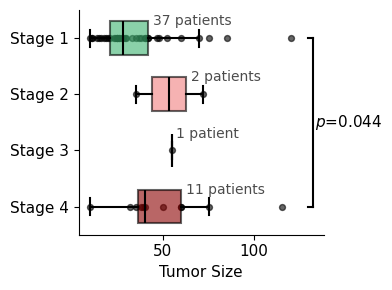

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

df = merged_df.copy()

# Clean
d = df[["stage", "Tumor size"]].dropna()
d["stage"] = d["stage"].astype(int)
d["Tumor size"] = d["Tumor size"].astype(float)

# Keep stages 1–4
d = d[d["stage"].isin([1,2,3,4])]

# Data (reverse order so Stage 1 appears at top)
stage_data = [
    d[d.stage == 4]["Tumor size"],
    d[d.stage == 3]["Tumor size"],
    d[d.stage == 2]["Tumor size"],
    d[d.stage == 1]["Tumor size"]
]

labels = ["Stage 4", "Stage 3", "Stage 2", "Stage 1"]

# Sample sizes
counts = [len(x) for x in stage_data]

# Mann–Whitney test (Stage 1 vs Stage 4)
stage1 = d[d.stage == 1]["Tumor size"]
stage4 = d[d.stage == 4]["Tumor size"]
stat, p = mannwhitneyu(stage1, stage4, alternative="two-sided")

fig, ax = plt.subplots(figsize=(4,3))

boxprops = dict(linewidth=1.5)
medianprops = dict(linewidth=1.5, color="black")
whiskerprops = dict(linewidth=1.5)
capprops = dict(linewidth=1.5)

bplot = ax.boxplot(
    stage_data,
    vert=False,
    labels=labels,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops
)

# Colors
colors = ["darkred", "indianred", "lightcoral", "mediumseagreen"]
for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay points
for i, vals in enumerate(stage_data, start=1):
    ax.scatter(vals, [i]*len(vals), alpha=0.6, color="black", s=18)

# Sample size labels
x_offset = np.max(d["Tumor size"]) * 0.02
print(x_offset)
for i, (vals, n) in enumerate(zip(stage_data, counts), start=1):
    ax.text(np.percentile(vals, 75) + x_offset, i + 0.30 , f"{n} patients" if n > 1 else f"{n} patient", va="center", fontsize=10, alpha=0.7)

# ----- p-value bracket (Stage 1 vs Stage 4) -----
x_bracket = d["Tumor size"].max() * 1.10
y1 = 1   # Stage 4
y4 = 4   # Stage 1

ax.plot([x_bracket, x_bracket], [y1, y4], color="black", lw=1.5)
ax.plot([x_bracket*0.98, x_bracket], [y1, y1], color="black", lw=1.5)
ax.plot([x_bracket*0.98, x_bracket], [y4, y4], color="black", lw=1.5)

ax.text(x_bracket*1.01, (y1+y4)/2, f"$p$={p:.2g}", va="center", fontsize=11)

# Labels
ax.set_xlabel("Tumor Size", fontsize=11)
ax.tick_params(axis="both", labelsize=11)

# Minimal axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/figures/tracerx_stage_vs_tumor_size_boxplot.svg")
# plt.show()

In [13]:
print(np.median(merged_df[merged_df['stage'] == 1.0]['Tumor size']))
print(np.median(merged_df[merged_df['stage'] == 4.0]['Tumor size']))

28.0
40.0
